 Feature Importance through XGBoost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.api as sm
import seaborn as sns
from xgboost import XGBRegressor, XGBClassifier
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# df_cat: raw categoricals version, used for XGBoost feature importance
df_cat = pd.read_pickle("../cleaned_datasets/df_cat.pkl")

**XGBoost for feature importance**
logic pipeline:
   1. Baseline XGBoost — benchmark R²
   2. RandomizedSearchCV — hyperparameter tuning (n_iter=50)
   3. Final model on best params — extract feature importance

In [24]:
#xgboost on df_cat
X_cat = df_cat.drop(columns=[target])
y_cat = df_cat[target]

#param_dist = {
#    "n_estimators"     : [200, 300, 400, 500, 600],
#    "max_depth"        : [3, 4, 5, 6, 7, 8],
#    "learning_rate"    : [0.01, 0.03, 0.05, 0.07, 0.1, 0.15],
#    "subsample"        : [0.6, 0.7, 0.8, 0.9, 1.0],
#    "colsample_bytree" : [0.6, 0.7, 0.8, 0.9, 1.0],
#    "min_child_weight" : [1, 3, 5, 7],
#    "gamma"            : [0, 0.1, 0.2, 0.3, 0.5],
#    "reg_alpha"        : [0, 0.01, 0.1, 0.5, 1.0],
#    "reg_lambda"       : [0.5, 1.0, 1.5, 2.0, 5.0],
#}

#random_search = RandomizedSearchCV(
#    estimator           = XGBRegressor(
#                            random_state       = 42,
#                            n_jobs             = -1,
#                            tree_method        = "hist",
#                            enable_categorical = True,
#                          ),
#    param_distributions = param_dist,
#    n_iter              = 50,
#    scoring             = "r2",
#    cv                  = KFold(n_splits=5, shuffle=True, random_state=42),
#    verbose             = 1,
#    random_state        = 42,
#    n_jobs              = -1,
#    refit               = True,
#)

#random_search.fit(X_cat, y_cat)

#print(f"\nBest CV R²  : {random_search.best_score_:.4f}")
#print(f"\nBest params :")
#for param, val in sorted(random_search.best_params_.items()):
#    print(f"  {param:<25} : {val}")

In [25]:
#xgb_best_params = random_search.best_params_

In [26]:
xgb_best_params = {
    "colsample_bytree" : 1.0,
    "gamma"            : 0,
    "learning_rate"    : 0.1,
    "max_depth"        : 7,
    "min_child_weight" : 3,
    "n_estimators"     : 400,
    "reg_alpha"        : 0.1,
    "reg_lambda"       : 0.5,
    "subsample"        : 0.9,
}

In [27]:
final_xgb = XGBRegressor(
    **xgb_best_params,
    random_state       = 42,
    n_jobs             = -1,
    tree_method        = "hist",
    enable_categorical = True,
)

final_cv = cross_val_score(
    final_xgb, X_cat, y_cat,
    cv      = KFold(n_splits=5, shuffle=True, random_state=42),
    scoring = "r2",
    n_jobs  = -1,
)

final_xgb.fit(X_cat, y_cat)

rmse_log = np.sqrt(mean_squared_error(y_cat, final_xgb.predict(X_cat)))
rmse_sgd = np.sqrt(mean_squared_error(np.exp(y_cat), np.exp(final_xgb.predict(X_cat))))
print(rmse_log, rmse_sgd)

# feature importance
feat_imp = (
    pd.Series(final_xgb.feature_importances_, index=X_cat.columns)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", 0: "importance"})
)
print(feat_imp.head(20).to_string(index=False))

0.04414210621599348 30156.773092309257
                            feature  importance
                          flat_type    0.555340
                     floor_area_sqm    0.180978
                               town    0.076214
                         flat_model    0.072802
          num_unique_mrt_lines_500m    0.023839
                         dist_cbd_m    0.016729
            remaining_lease_numeric    0.016401
                       storey_range    0.011933
                num_unique_mrt_500m    0.011129
                 walking_dist_mrt_m    0.007042
nearest_tier1_primary_school_dist_m    0.003464
                walking_dist_mall_m    0.003225
                      num_malls_1km    0.003120
                      num_malls_2km    0.003010
              num_unique_hawker_1km    0.002687
           num_unique_mrt_lines_1km    0.002572
             num_unique_hawker_500m    0.002355
                 num_unique_mrt_1km    0.001933
                  num_busstops_500m    0.001667
 

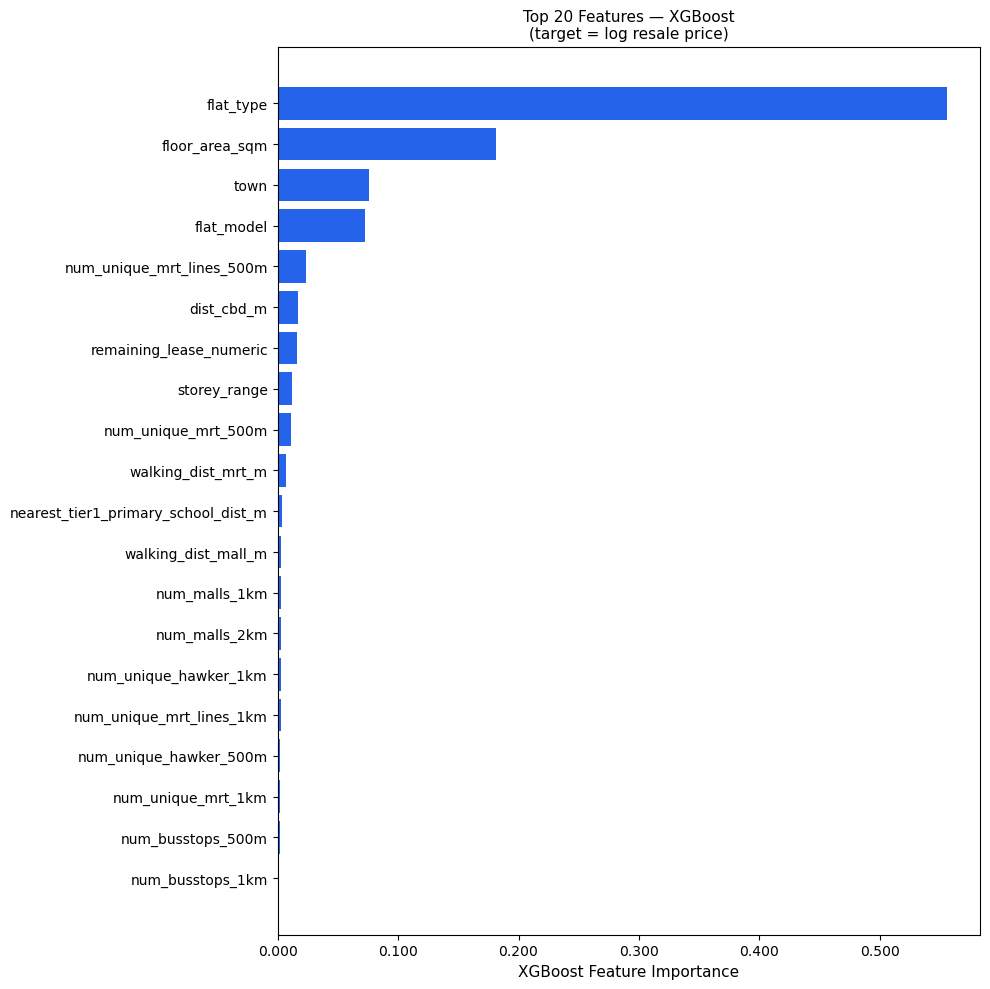

In [28]:
#feature importance 
top_20 = feat_imp.head(20)

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(top_20["feature"][::-1], top_20["importance"][::-1], color="#2563EB")
ax.set_xlabel("XGBoost Feature Importance", fontsize=11)
ax.set_title(f"Top {len(top_20)} Features — XGBoost\n(target = log resale price)",
             fontsize=11)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))

plt.tight_layout()
plt.savefig("xgb_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
